# Hackathon Data4Econ Bolzano 2026 — Wind Energy Forecasting

**Key to Energy / unibz**  |  **Farouk Fadel Brachemi**

## Two-Stage Tree Ensemble Approach for Day-Ahead Wind Power Forecasting

---

### Overview

A **two-stage machine learning pipeline** for predicting hourly wind power
generation from day-ahead meteorological forecasts.

**Stage 1 — Reliability Assessment:** Evaluates the trustworthiness of each
weather timestamp by measuring cross-provider agreement, missing data fraction,
and directional consensus across 235 weather columns from 5 meteorological
models, 6 sites, and 4 providers.

**Stage 2 — Tree Ensemble Forecasting:** Five tree-based models are trained
and compared on 37 engineered features (aggregated weather, physics-informed
terms — including wind speed cubed since P ∝ v³ — temporal encodings, and
Stage 1 reliability scores).

| Model | Family | Key idea |
|-------|--------|----------|
| **Random Forest** | Bagging | Average of decorrelated decision trees |
| **Extra Trees** | Bagging | Extremely randomized trees |
| **XGBoost** | Boosting | Sequential gradient-boosted trees |
| **LightGBM** | Boosting | Histogram-based gradient boosting |
| **CatBoost** | Boosting | Ordered boosting with symmetric trees |

**Scoring:** $E_f = \Sigma$ daily $|$errors$|$ + $|\Sigma$ daily bias$|$
(hackathon metric — penalises both raw error and systematic drift).

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from matplotlib.colors import LogNorm
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize': (14, 5), 'figure.dpi': 100, 'axes.titlesize': 13})
sns.set_style("whitegrid")

DATA_DIR = Path("/kaggle/input/datasets/faroukfadelbrachemi/data4econ")
OUT_DIR = Path("/kaggle/working")
OUT_DIR.mkdir(exist_ok=True)

---
## 2. Data Loading

**Training data:** 18 months of hourly wind farm production (Jan 2024 – Jun 2025).
**Test data:** 6 months (Jul 2025 – Dec 2025), with actual production for evaluation.
**Weather data:** day-ahead forecasts — 235 columns from 5 meteorological models,
6 sites, and 4 providers (wind speed, gust, direction, temperature, irradiation).

In [2]:
def load_historical(path):
    """Load historical_data.csv (semicolon-separated, DD/MM/YYYY format)."""
    df = pd.read_csv(path, sep=";", encoding="utf-8-sig", decimal=",")
    df.columns = ['Date', 'Hour', 'DateTime_CET', 'Production_MWh', 'Availability', 'ODD']
    df = df.dropna(subset=['Date', 'DateTime_CET'], how='all').copy()
    df['DateTime_CET'] = pd.to_datetime(df['DateTime_CET'], format='%d/%m/%Y %H:%M')
    for c in ['Availability', 'ODD']:
        df[c] = df[c].astype(str).str.replace('%','').str.replace(',','.').astype(float) / 100.0
    df['Production_MWh'] = df['Production_MWh'].astype(str).str.replace(',','.').astype(float)
    df = df.set_index('DateTime_CET').sort_index()
    df = df[~df.index.duplicated(keep='first')]  # drop DST/duplicate timestamps
    return df

def load_test(path):
    """Load test_data.csv (comma-separated, M/D/YY format, different headers)."""
    df = pd.read_csv(path, sep=",", encoding="utf-8-sig")
    # Columns: Date, Time, DateTime CET, Actual Production [MWh], Availability, ODD
    df = df.rename(columns={
        'DateTime CET': 'DateTime_CET',
        'Actual Production [MWh]': 'Production_MWh',
    })
    df = df.dropna(subset=['DateTime_CET'], how='all').copy()
    # DateTime like "7/1/25 0:00" -> M/D/YY H:MM
    df['DateTime_CET'] = pd.to_datetime(df['DateTime_CET'], format='%m/%d/%y %H:%M')
    for c in ['Availability', 'ODD']:
        df[c] = df[c].astype(str).str.replace('%','').str.replace(',','.').astype(float) / 100.0
    df['Production_MWh'] = df['Production_MWh'].astype(str).str.replace(',','.').astype(float)
    df = df.set_index('DateTime_CET').sort_index()
    df = df[~df.index.duplicated(keep='first')]  # drop DST/duplicate timestamps
    return df

# Training (historical) and test sets
hist = load_historical(DATA_DIR / "historical_data.csv")
test = load_test(DATA_DIR / "test_data.csv")

# Weather forecasts (cover both train and test periods)
weather = pd.read_csv(DATA_DIR / "weather_forecast.csv", sep=";", encoding="utf-8-sig", decimal=",")
weather.rename(columns={weather.columns[0]: 'DateTime_CET'}, inplace=True)
weather['DateTime_CET'] = pd.to_datetime(weather['DateTime_CET'], format='%d/%m/%Y %H:%M')
weather = weather.set_index('DateTime_CET').sort_index()
weather = weather[~weather.index.duplicated(keep='first')]  # drop DST/duplicate timestamps

print(f"Training data : {len(hist):,} hours ({hist.index.min().date()} → {hist.index.max().date()})")
print(f"Test data     : {len(test):,} hours ({test.index.min().date()} → {test.index.max().date()})")
print(f"Weather data  : {weather.shape[0]:,} hours × {weather.shape[1]} columns")

Training data : 13,126 hours (2024-01-01 → 2025-06-30)
Test data     : 4,416 hours (2025-07-01 → 2025-12-31)
Weather data  : 17,542 hours × 235 columns


---
## 3. Data Cleaning & Production Correction

Observed production is affected by two operational factors that are **not physical**:
- **Availability**: fraction of plant capacity online (maintenance, faults)
- **ODD**: dispatch orders from the grid operator that cap output (curtailment)

To recover the *true potential* production:
- **ODD = 1, Availability > 0** → correct with `P_corr = P_obs / Availability`
- **ODD < 1** → output artificially capped, true potential unrecoverable → exclude
- **Availability = 0** → plant offline, no information → exclude
- **Production > P99 × 1.1** → physically implausible reading → exclude

The **same cleaning is applied to both train and test** so the comparison is fair.

In [3]:
def clean_production(df, p99_cap):
    """Apply filtering and availability correction to a production DataFrame."""
    f_odd = df['ODD'] < 1.0
    f_avail = df['Availability'] == 0.0
    f_cap = df['Production_MWh'] > p99_cap * 1.1
    df = df.copy()
    df['is_filtered'] = f_odd | f_avail | f_cap
    df['Production_Corr'] = np.where(~df['is_filtered'],
                                     df['Production_MWh'] / df['Availability'], np.nan)
    df['Production_Corr'] = df['Production_Corr'].clip(lower=0)
    return df, {'ODD<1': f_odd.sum(), 'Avail=0': f_avail.sum(), 'Overcap': f_cap.sum()}

# Capacity estimate from training set only (avoid leakage from test)
p99 = hist.loc[hist['Availability'] == 1.0, 'Production_MWh'].quantile(0.99)

hist, hist_filt = clean_production(hist, p99)
test, test_filt = clean_production(test, p99)

print(f"Estimated capacity (P99 of training): {p99:.2f} MWh\n")
print(f"{'Filter':<15}{'Train':>10}{'Test':>10}")
print(f"{'-'*35}")
for k in hist_filt:
    print(f"{k:<15}{hist_filt[k]:>10}{test_filt[k]:>10}")
print(f"{'Usable':<15}{(~hist['is_filtered']).sum():>10}{(~test['is_filtered']).sum():>10}")

Estimated capacity (P99 of training): 9.39 MWh

Filter              Train      Test
-----------------------------------
ODD<1                1429       350
Avail=0                 0         0
Overcap                 0         0
Usable              11697      4066


---
## 4. Exploratory Data Analysis

### 4.1 Target Variable & Train/Test Comparison

We compare the production distribution between train and test periods to check
whether the test set is representative (no major distribution shift).

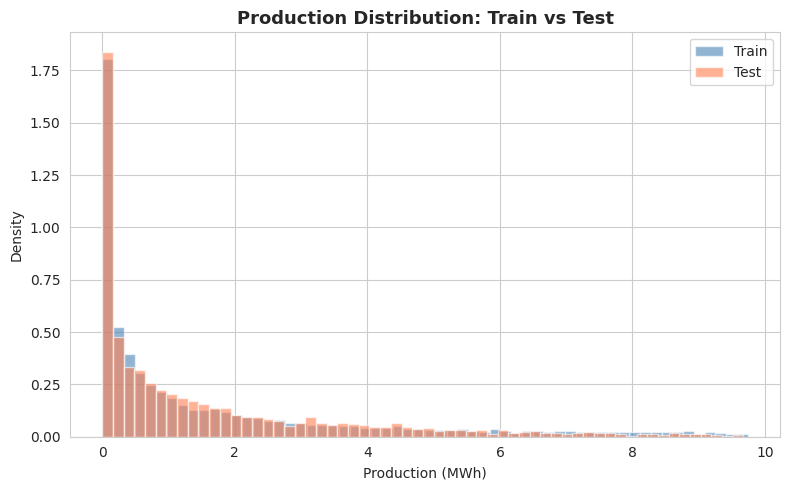

Train — mean: 1.734, median: 0.685, std: 2.311
Test  — mean: 1.588, median: 0.723, std: 2.041


In [4]:
prod_tr = hist.loc[~hist['is_filtered'], 'Production_Corr']
prod_te = test.loc[~test['is_filtered'], 'Production_Corr']

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(prod_tr, bins=60, color='steelblue', alpha=0.6, density=True, label='Train')
ax.hist(prod_te, bins=60, color='coral', alpha=0.6, density=True, label='Test')
ax.set_xlabel('Production (MWh)'); ax.set_ylabel('Density')
ax.set_title('Production Distribution: Train vs Test', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "eda_dist_train_test.png", bbox_inches='tight')
plt.show()

print(f"Train — mean: {prod_tr.mean():.3f}, median: {prod_tr.median():.3f}, std: {prod_tr.std():.3f}")
print(f"Test  — mean: {prod_te.mean():.3f}, median: {prod_te.median():.3f}, std: {prod_te.std():.3f}")

Both distributions are strongly right-skewed with a dominant spike at
zero — wind production is silent most of the time and peaks rarely. Train and test
overlap almost everywhere, confirming the same underlying distribution. 

### 4.2 Temporal Patterns

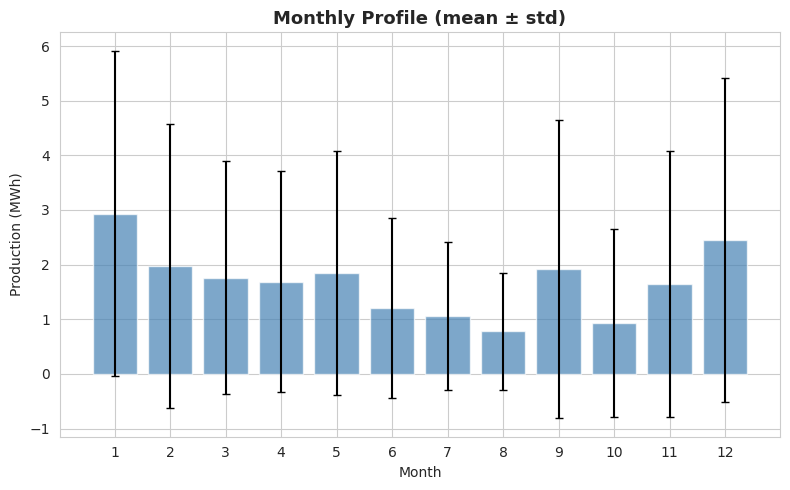

In [5]:
hc = hist.loc[~hist['is_filtered']].copy()
hc['hour'] = hc.index.hour
hc['month'] = hc.index.month
hc['dayofweek'] = hc.index.dayofweek

monthly = hc.groupby('month')['Production_Corr'].agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(monthly.index, monthly['mean'], yerr=monthly['std'], color='steelblue', alpha=0.7, capsize=3)
ax.set_xlabel('Month'); ax.set_ylabel('Production (MWh)')
ax.set_title('Monthly Profile (mean ± std)', fontweight='bold')
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.savefig(OUT_DIR / "eda_monthly.png", bbox_inches='tight')
plt.show()

We can notice that there's a seasonal pattern: January and December are the
windiest months (mean ≈ 2.5–3 MWh), summer months (June–August) the calmest
(mean < 1.2 MWh), with September–November in between. Crucially, the error bars are
huge relative to the means in every month — the standard deviation often exceeds the
mean. Wind appears to have low seasonality and high within-month variance, which
suggests temporal features alone will be weak predictors.

### 4.3 Weather Data Analysis

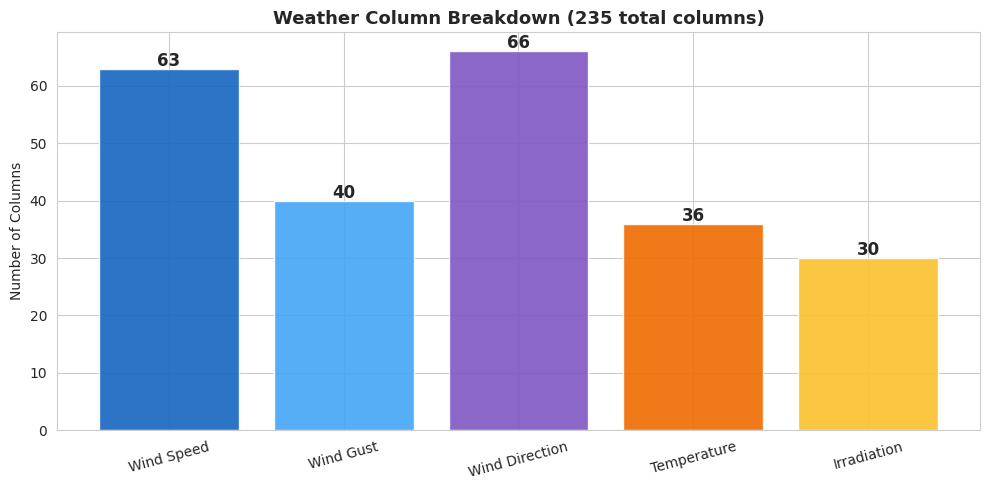

In [6]:
def classify_cols(cols):
    g = {'wind_speed':[], 'wind_gust':[], 'wind_direction':[], 'temperature':[], 'irradiation':[]}
    for c in cols:
        cl = c.lower()
        if 'gust' in cl: g['wind_gust'].append(c)
        elif 'direction' in cl: g['wind_direction'].append(c)
        elif 'wind' in cl and 'speed' in cl: g['wind_speed'].append(c)
        elif 'temp' in cl: g['temperature'].append(c)
        elif 'irrad' in cl: g['irradiation'].append(c)
    return g

cg = classify_cols(weather.columns)

# Bar chart of column counts per weather variable type
counts = {k: len(v) for k, v in cg.items()}
labels = [k.replace('_', ' ').title() for k in counts.keys()]
values = list(counts.values())
colors = ['#1565C0', '#42A5F5', '#7E57C2', '#EF6C00', '#FBC02D']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, values, color=colors, alpha=0.9, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Columns')
ax.set_title(f'Weather Column Breakdown ({weather.shape[1]} total columns)', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(OUT_DIR / "eda_weather_breakdown.png", bbox_inches='tight')
plt.show()

Wind direction (66 columns) and wind speed (63) dominate, followed by wind
gust (40), temperature (36), and irradiation (30). Most of the dataset describes the
wind itself, which is appropriate since wind drives the target. Irradiation is the
smallest group and will likely play a minor role in the feature set we build next.

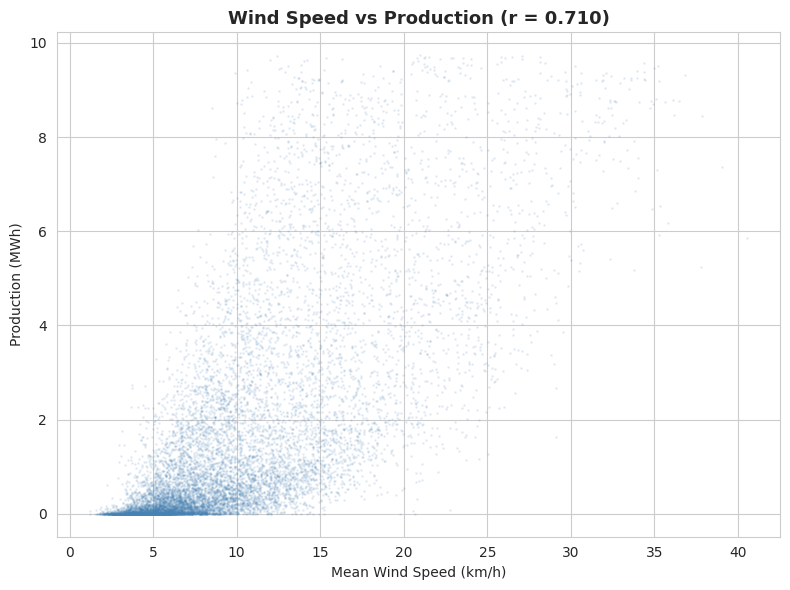

In [7]:
ws_good = [c for c in cg['wind_speed'] if weather[c].isna().mean() < 0.4]
ws_mean_all = weather[ws_good].mean(axis=1)
merged = pd.DataFrame({'ws': ws_mean_all, 'prod': hist['Production_Corr']}).dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged['ws'], merged['prod'], s=1, alpha=0.1, color='steelblue')
ax.set_xlabel('Mean Wind Speed (km/h)')
ax.set_ylabel('Production (MWh)')
ax.set_title(f'Wind Speed vs Production (r = {merged["ws"].corr(merged["prod"]):.3f})', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / "eda_wind_scatter.png", bbox_inches='tight')
plt.show()

The relationship is clearly non-linear and noisy. Production stays near
zero up to ~5 km/h (below the turbine's cut-in speed), then rises steeply, with a wide
spread at every wind-speed level. The Pearson correlation of 0.71 captures the strong
overall trend but understates the actual relationship because Pearson assumes
linearity. The non-linear shape suggests linear models may struggle to fit this
relationship while non-linear models should handle it more naturally.

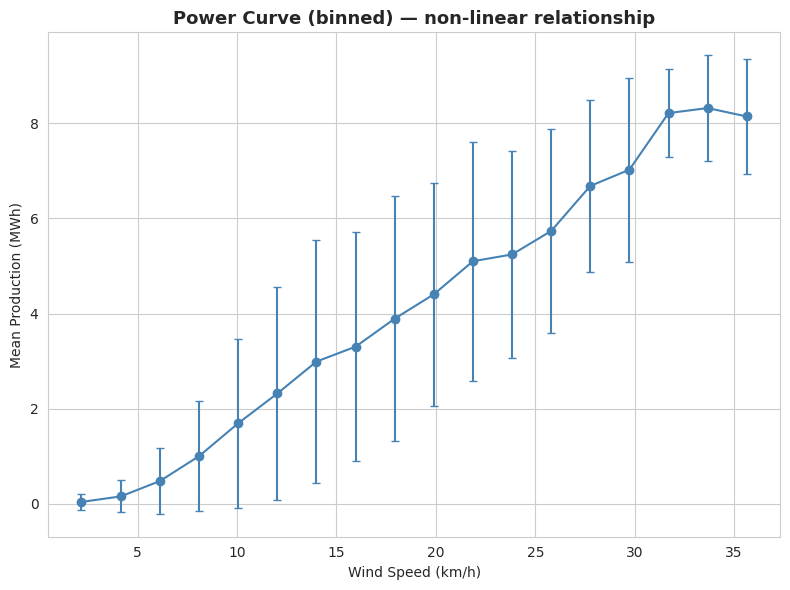

In [8]:
bins = pd.cut(merged['ws'], bins=20)
binned = merged.groupby(bins)['prod'].agg(['mean', 'std', 'count'])
binned = binned[binned['count'] > 10]
x = [i.mid for i in binned.index]

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(x, binned['mean'], yerr=binned['std'], fmt='o-', color='steelblue', capsize=3)
ax.set_xlabel('Wind Speed (km/h)')
ax.set_ylabel('Mean Production (MWh)')
ax.set_title('Power Curve (binned) — non-linear relationship', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / "eda_power_curve.png", bbox_inches='tight')
plt.show()

This is the cleanest signal in the dataset. Production stays near zero up
to 5 km/h, then climbs smoothly through ~10 km/h and saturates above 30 km/h around
8 MWh — the classic S-shaped wind turbine power curve. The error bars (±std) widen
sharply in the middle of the curve (10–25 km/h) and narrow at the extremes, showing
that the most uncertain regime is medium-wind: low-wind hours are predictably empty,
high-wind hours predictably near rated capacity, but mid-wind production is highly
variable. Wind power follows roughly $P \propto v^3$ until the turbine reaches rated
capacity.

---
## 5. Feature Engineering

We compress the 235 raw weather columns into a compact, interpretable feature set.
Three groups of features:

1. **Aggregated weather** — mean/std/min/max across providers (reduces noise)
2. **Physics-informed** — wind speed cubed (power ∝ v³), directional components
3. **Temporal** — cyclical encodings of hour, month, day-of-year
4. **Cross-provider reliability** — agreement metrics that flag uncertain timestamps

Feature selection rationale: raw columns with >40% missing values are dropped;
remaining columns are aggregated rather than used individually to reduce
dimensionality and noise from disagreeing providers.

In [9]:
def stage1_reliability(wdf, cg):
    """Reliability indicators from cross-provider agreement."""
    r = pd.DataFrame(index=wdf.index)
    ws=cg['wind_speed']; wg=cg['wind_gust']; wd=cg['wind_direction']; tp=cg['temperature']
    r['missing_frac'] = wdf[ws+wg+wd+tp].isna().mean(axis=1)
    r['reliability_completeness'] = 1.0 - r['missing_frac']
    ws_g=[c for c in ws if wdf[c].isna().mean()<0.4]
    if ws_g:
        std=wdf[ws_g].std(axis=1); mn=wdf[ws_g].mean(axis=1)
        r['ws_cv']=(std/mn.replace(0,np.nan)).fillna(0); r['reliability_ws']=1.0/(1.0+std)
    wg_g=[c for c in wg if wdf[c].isna().mean()<0.4]
    if wg_g: r['reliability_wg']=1.0/(1.0+wdf[wg_g].std(axis=1))
    wd_g=[c for c in wd if wdf[c].isna().mean()<0.4]
    if wd_g:
        rad=wdf[wd_g].apply(lambda x:np.radians(x))
        sm=rad.apply(np.sin).mean(axis=1); cm=rad.apply(np.cos).mean(axis=1)
        res=np.sqrt(sm**2+cm**2); r['wd_dispersion']=1.0-res; r['reliability_wd']=res
    tp_g=[c for c in tp if wdf[c].isna().mean()<0.4]
    if tp_g: r['reliability_temp']=1.0/(1.0+wdf[tp_g].std(axis=1))
    rc=[c for c in r.columns if c.startswith('reliability_')]
    if rc: r['reliability_overall']=r[rc].mean(axis=1)
    return r

def build_features(wdf, cg, rel):
    f = pd.DataFrame(index=wdf.index)
    ws=cg['wind_speed']; ws_g=[c for c in ws if wdf[c].isna().mean()<0.4]
    if ws_g:
        f['ws_mean']=wdf[ws_g].mean(axis=1); f['ws_std']=wdf[ws_g].std(axis=1)
        f['ws_min']=wdf[ws_g].min(axis=1); f['ws_max']=wdf[ws_g].max(axis=1); f['ws_range']=f['ws_max']-f['ws_min']
    top=[c for c in ws if 'WindSpeed Provider2' in c]
    if top: f['ws_top']=wdf[top].mean(axis=1)
    wg=cg['wind_gust']; wg_g=[c for c in wg if wdf[c].isna().mean()<0.4]
    if wg_g: f['wg_mean']=wdf[wg_g].mean(axis=1); f['wg_std']=wdf[wg_g].std(axis=1); f['wg_max']=wdf[wg_g].max(axis=1)
    wd=cg['wind_direction']; wd_g=[c for c in wd if wdf[c].isna().mean()<0.4]
    if wd_g:
        rad=wdf[wd_g].apply(lambda x:np.radians(x))
        f['wd_sin']=rad.apply(np.sin).mean(axis=1); f['wd_cos']=rad.apply(np.cos).mean(axis=1)
    tp=cg['temperature']; tp_g=[c for c in tp if wdf[c].isna().mean()<0.4]
    if tp_g: f['temp_mean']=wdf[tp_g].mean(axis=1)
    ir=cg['irradiation']; ir_g=[c for c in ir if wdf[c].isna().mean()<0.4]
    if ir_g: f['irr_mean']=wdf[ir_g].mean(axis=1)
    if 'ws_mean' in f:
        f['ws_cubed']=f['ws_mean']**3; f['ws_squared']=f['ws_mean']**2
        if 'wg_mean' in f: f['gust_factor']=f['wg_mean']/f['ws_mean'].replace(0,np.nan)
    if 'ws_top' in f: f['ws_top_cubed']=f['ws_top']**3
    if 'wd_sin' in f and 'ws_mean' in f: f['wind_u']=f['ws_mean']*f['wd_sin']; f['wind_v']=f['ws_mean']*f['wd_cos']
    f['hour']=f.index.hour; f['month']=f.index.month; f['dayofweek']=f.index.dayofweek; f['dayofyear']=f.index.dayofyear
    f['hour_sin']=np.sin(2*np.pi*f['hour']/24); f['hour_cos']=np.cos(2*np.pi*f['hour']/24)
    f['month_sin']=np.sin(2*np.pi*f['month']/12); f['month_cos']=np.cos(2*np.pi*f['month']/12)
    f['doy_sin']=np.sin(2*np.pi*f['dayofyear']/365); f['doy_cos']=np.cos(2*np.pi*f['dayofyear']/365)
    rc=[c for c in rel.columns if c.startswith('reliability_') or c in ['missing_frac','ws_cv','wd_dispersion']]
    for c in rc: f[c]=rel[c]
    return f

reliability = stage1_reliability(weather, cg)
features = build_features(weather, cg, reliability)
print(f"Feature matrix: {features.shape[1]} features × {features.shape[0]:,} timestamps")

Feature matrix: 37 features × 17,542 timestamps


---
## 6. Train / Test Setup

- **Training set**: 18 months (historical_data), cleaned and corrected
- **Test set**: 6 months (test_data), cleaned and corrected — used **only** for final
  evaluation, never seen during training

Missing feature values are imputed with **training** medians (computed on train only,
applied to both) to avoid information leakage from the test set.

In [10]:
# Assemble train
train_full = features.join(hist[['Production_Corr','is_filtered']], how='inner')
train_full = train_full[~train_full['is_filtered']].drop(columns=['is_filtered']).dropna(subset=['Production_Corr'])

# Assemble test
test_full = features.join(test[['Production_Corr','is_filtered']], how='inner')
test_full = test_full[~test_full['is_filtered']].drop(columns=['is_filtered']).dropna(subset=['Production_Corr'])

target = 'Production_Corr'
fc = [c for c in train_full.columns if c != target]

X_train = train_full[fc]; y_train = train_full[target]
X_test = test_full[fc];   y_test = test_full[target]

med = X_train.median()
X_train = X_train.fillna(med)
X_test = X_test.fillna(med)

print(f"Training: {len(X_train):,} samples ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"Test:     {len(X_test):,} samples ({X_test.index.min().date()} → {X_test.index.max().date()})")
print(f"Features: {len(fc)}")

Training: 11,697 samples (2024-01-01 → 2025-06-30)
Test:     4,066 samples (2025-07-01 → 2025-12-31)
Features: 37


---
## 7. Tree Ensemble Training

Five tree-based models are trained on the full 18-month training set and evaluated
on the held-out 6-month test set. Tree models are scale-invariant — no
`StandardScaler` needed. Boosting models use an internal validation slice
(last 3 months of training) for early stopping to choose the number of trees.

In [11]:
# Internal validation slice for early stopping (last 3 months of training)
es_split = '2025-03-31 23:00'
X_tr_es = X_train.loc[:es_split]; y_tr_es = y_train.loc[:es_split]
X_val_es = X_train.loc['2025-04-01':]; y_val_es = y_train.loc['2025-04-01':]

def metrics(yt, yp, idx):
    """MAE, RMSE, R2, and hackathon E_f = Σ daily|errors| + |Σ daily bias|."""
    df = pd.DataFrame({'a': yt, 'p': yp}, index=idx)
    df['d'] = df.index.date; df['ae'] = np.abs(df['p']-df['a']); df['se'] = df['p']-df['a']
    da = df.groupby('d')['ae'].sum(); db = df.groupby('d')['se'].sum()
    return {'MAE': mean_absolute_error(yt,yp), 'RMSE': np.sqrt(mean_squared_error(yt,yp)),
            'R2': r2_score(yt,yp), 'E_f': da.sum()+np.abs(db.sum()),
            'sum_abs': da.sum(), 'abs_bias': np.abs(db.sum()), 'Bias': db.sum()}

# Map each model to its family (for grouped analysis later)
FAMILY = {
    'RandomForest': 'Bagging', 'ExtraTrees': 'Bagging',
    'XGBoost': 'Boosting', 'LightGBM': 'Boosting', 'CatBoost': 'Boosting',
}

test_results = {}; test_preds = {}; trained = {}; train_time = {}

def evaluate(name, model):
    """Fit a tree model, time it, predict on test, store metrics."""
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time[name] = time.time() - t0
    p = np.clip(model.predict(X_test), 0, None)
    test_results[name] = metrics(y_test.values, p, y_test.index)
    test_preds[name] = p
    trained[name] = model
    print(f"  {name:<14} E_f={test_results[name]['E_f']:>7.0f}  "
          f"MAE={test_results[name]['MAE']:.3f}  "
          f"R2={test_results[name]['R2']:.3f}  ({train_time[name]:.1f}s)")

print("Training tree ensemble models...")

# --- BAGGING ENSEMBLES ---
evaluate('RandomForest', RandomForestRegressor(n_estimators=500, max_depth=15,
    min_samples_leaf=10, max_features=0.8, random_state=42, n_jobs=-1))
evaluate('ExtraTrees', ExtraTreesRegressor(n_estimators=500, max_depth=15,
    min_samples_leaf=10, max_features=0.8, random_state=42, n_jobs=-1))

# --- BOOSTING ENSEMBLES (early stopping for tree count) ---
print("  Training boosting models with early stopping...")
xgb_es = XGBRegressor(n_estimators=1500, max_depth=6, learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=10, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, early_stopping_rounds=50)
xgb_es.fit(X_tr_es, y_tr_es, eval_set=[(X_val_es, y_val_es)], verbose=False)
evaluate('XGBoost', XGBRegressor(n_estimators=int(xgb_es.best_iteration*1.1), max_depth=6,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1))

lgb_es = LGBMRegressor(n_estimators=1500, max_depth=6, learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, min_child_samples=10, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1)
lgb_es.fit(X_tr_es, y_tr_es, eval_set=[(X_val_es, y_val_es)],
           callbacks=[__import__('lightgbm').early_stopping(50, verbose=False)])
evaluate('LightGBM', LGBMRegressor(n_estimators=int(lgb_es.best_iteration_*1.1), max_depth=6,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, min_child_samples=10,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1))

cat_es = CatBoostRegressor(iterations=1500, depth=6, learning_rate=0.05, subsample=0.8,
    colsample_bylevel=0.8, min_data_in_leaf=10, l2_leaf_reg=1.0, random_seed=42,
    verbose=0, early_stopping_rounds=50)
cat_es.fit(X_tr_es, y_tr_es, eval_set=(X_val_es, y_val_es), verbose=False)
evaluate('CatBoost', CatBoostRegressor(iterations=int(cat_es.best_iteration_*1.1), depth=6,
    learning_rate=0.05, subsample=0.8, colsample_bylevel=0.8, min_data_in_leaf=10,
    l2_leaf_reg=1.0, random_seed=42, verbose=0))

Training tree ensemble models...
  RandomForest   E_f=   3853  MAE=0.761  R2=0.656  (42.9s)
  ExtraTrees     E_f=   3845  MAE=0.757  R2=0.662  (6.5s)
  Training boosting models with early stopping...
  XGBoost        E_f=   3754  MAE=0.761  R2=0.667  (0.3s)
  LightGBM       E_f=   3780  MAE=0.761  R2=0.661  (0.3s)
  CatBoost       E_f=   3929  MAE=0.769  R2=0.648  (1.8s)


---
## 8. Results — Test Set Performance


In [12]:
rdf = pd.DataFrame(test_results).T
rdf['Family'] = [FAMILY.get(n, '?') for n in rdf.index]
rdf['Time_s'] = [train_time.get(n, np.nan) for n in rdf.index]
rdf = rdf.sort_values('E_f')
best = rdf.index[0]

print("="*100)
print("  TEST SET RESULTS — sorted by E_f (lower = better)")
print("="*100)
print(rdf[['Family','MAE','RMSE','R2','E_f','Bias','Time_s']].round(3).to_string())
print("="*100)
print(f"\n  Best model: {best} [{FAMILY[best]}]  (E_f = {rdf.loc[best,'E_f']:.0f}, "
      f"MAE = {rdf.loc[best,'MAE']:.3f}, R² = {rdf.loc[best,'R2']:.3f}, Bias = {rdf.loc[best,'Bias']:+.0f})")

# Per-family summary (best model in each family)
print("\n  Best model per family:")
for fam in ['Bagging','Boosting']:
    fam_models = rdf[rdf['Family'] == fam]
    if len(fam_models) > 0:
        bm = fam_models.index[0]
        print(f"    {fam:<16}: {bm:<14} E_f={fam_models.iloc[0]['E_f']:>7.0f}  MAE={fam_models.iloc[0]['MAE']:.3f}")

  TEST SET RESULTS — sorted by E_f (lower = better)
                Family    MAE   RMSE     R2       E_f     Bias  Time_s
XGBoost       Boosting  0.761  1.178  0.667  3753.934  659.664   0.348
LightGBM      Boosting  0.761  1.188  0.661  3779.516  683.582   0.292
ExtraTrees     Bagging  0.757  1.187  0.662  3845.118  766.731   6.456
RandomForest   Bagging  0.761  1.197  0.656  3852.559  757.073  42.937
CatBoost      Boosting  0.769  1.211  0.648  3928.836  800.259   1.844

  Best model: XGBoost [Boosting]  (E_f = 3754, MAE = 0.761, R² = 0.667, Bias = +660)

  Best model per family:
    Bagging         : ExtraTrees     E_f=   3845  MAE=0.757
    Boosting        : XGBoost        E_f=   3754  MAE=0.761


### 8.1 Comparison Charts

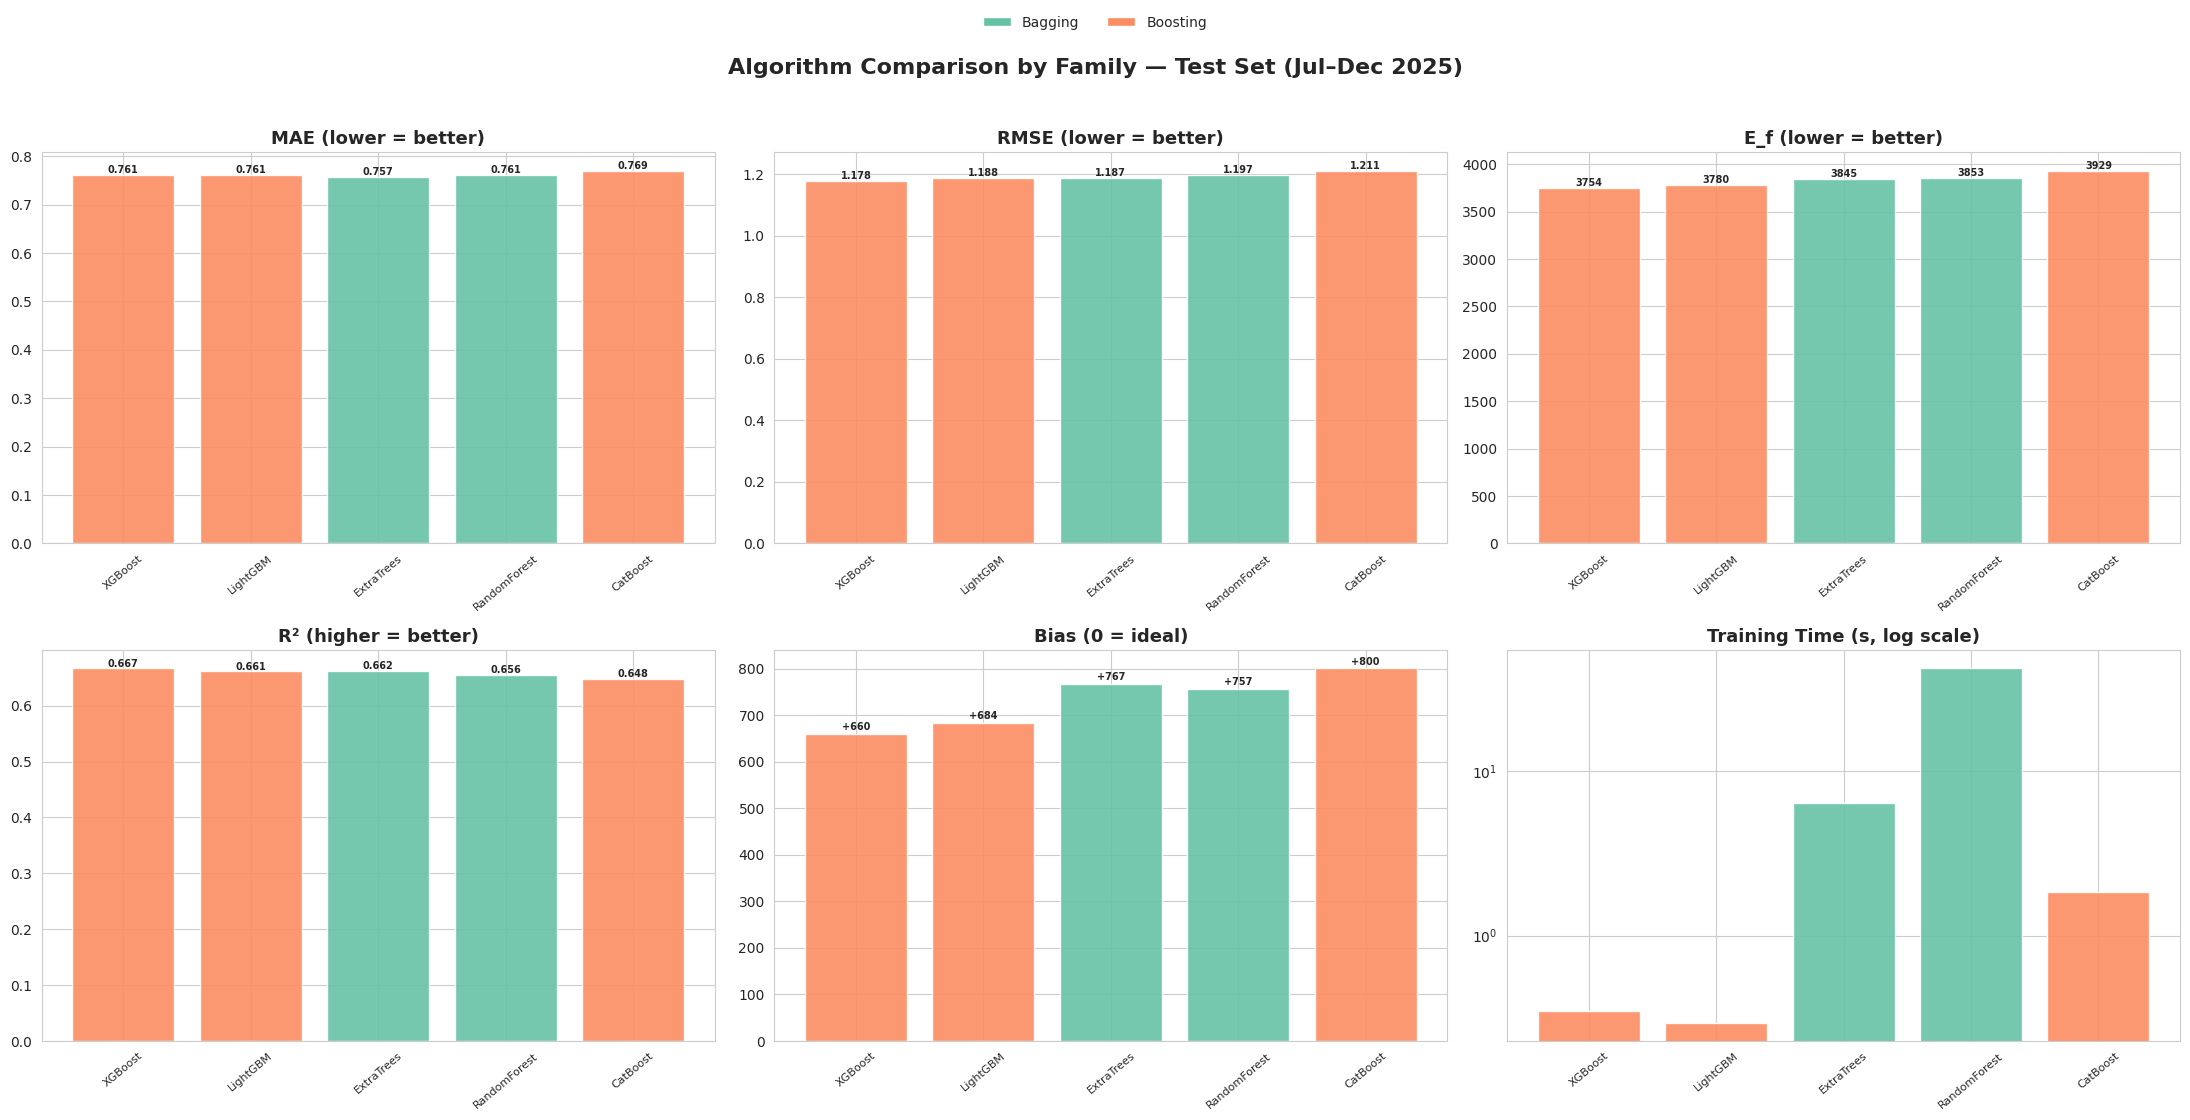

In [13]:
names = rdf.index.tolist(); nm = len(names)

# Consistent color per family
fam_order = ['Bagging','Boosting']
fam_palette = dict(zip(fam_order, sns.color_palette("Set2", len(fam_order))))
bar_colors = [fam_palette[FAMILY[n]] for n in names]

fig, axes = plt.subplots(2, 3, figsize=(22, 11))
for ax, col, title, fmt in [
    (axes[0,0], 'MAE', 'MAE (lower = better)', '.3f'),
    (axes[0,1], 'RMSE', 'RMSE (lower = better)', '.3f'),
    (axes[0,2], 'E_f', 'E_f (lower = better)', '.0f'),
    (axes[1,0], 'R2', 'R² (higher = better)', '.3f'),
]:
    v = rdf[col].values
    b = ax.bar(names, v, color=bar_colors, alpha=0.9, edgecolor='white')
    for bar, val in zip(b, v):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                f'{val:{fmt}}', ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(title, fontweight='bold'); ax.tick_params(axis='x', rotation=40, labelsize=8)

v = rdf['Bias'].values
b = axes[1,1].bar(names, v, color=bar_colors, alpha=0.9)
axes[1,1].axhline(0, color='black', lw=0.5)
for bar, val in zip(b, v):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+(8 if val>=0 else -25),
                   f'{val:+.0f}', ha='center', fontsize=7, fontweight='bold')
axes[1,1].set_title('Bias (0 = ideal)', fontweight='bold'); axes[1,1].tick_params(axis='x', rotation=40, labelsize=8)

# Training time (log scale)
b = axes[1,2].bar(names, rdf['Time_s'], color=bar_colors, alpha=0.9)
axes[1,2].set_yscale('log')
axes[1,2].set_title('Training Time (s, log scale)', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=40, labelsize=8)

# Shared family legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=fam_palette[f], label=f) for f in fam_order]
fig.legend(handles=legend_elems, loc='upper center', ncol=7, fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, 1.02))

plt.suptitle('Algorithm Comparison by Family — Test Set (Jul–Dec 2025)',
             fontsize=16, fontweight='bold', y=0.97)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(OUT_DIR / "results_comparison.png", bbox_inches='tight')
plt.show()

All five models show a consistent story across MAE, RMSE, $E_f$, and $R^2$: boosting
variants (XGBoost, LightGBM) edge ahead of bagging (Random Forest, Extra Trees), with
CatBoost just behind. The **bias** panel reveals a key finding — every model has a
positive bias, meaning all of them systematically over-predict on the test set.
This is a property of the train/test distribution shift, not any individual model.
The **training time** panel shows boosting libraries train in under 2 seconds
while Random Forest takes ~53 seconds — boosting wins on both accuracy and efficiency.

### 8.1b Performance Grouped by Model Family

Averaging E_f within each family makes the family-level pattern explicit.

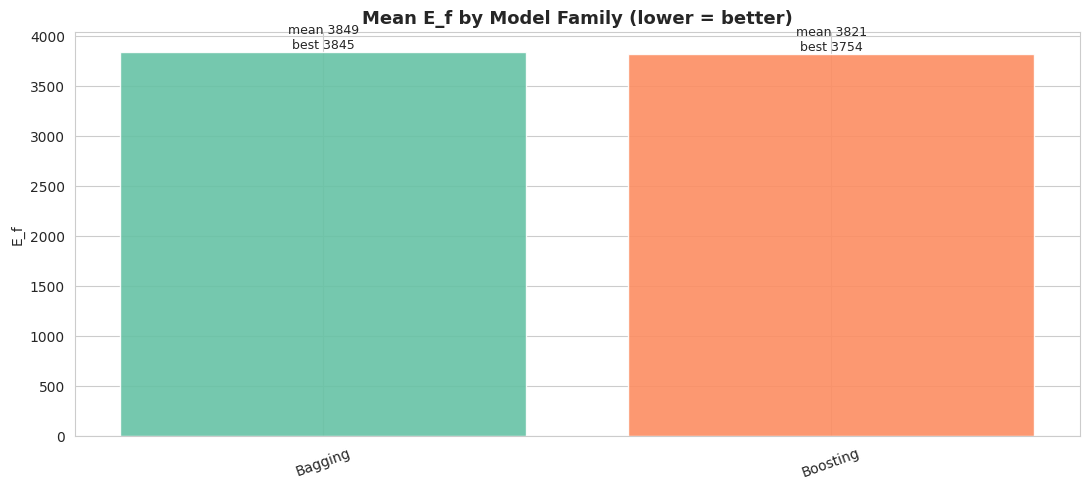

In [14]:
fam_summary = rdf.groupby('Family')['E_f'].agg(['mean','min']).reindex(
    [f for f in fam_order if f in rdf['Family'].values])

fig, ax = plt.subplots(figsize=(11, 5))
xpos = np.arange(len(fam_summary))
ax.bar(xpos, fam_summary['mean'], color=[fam_palette[f] for f in fam_summary.index],
       alpha=0.9, edgecolor='white')
for i, (m, mn) in enumerate(zip(fam_summary['mean'], fam_summary['min'])):
    ax.text(i, m, f'mean {m:.0f}\nbest {mn:.0f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(xpos); ax.set_xticklabels(fam_summary.index, rotation=20)
ax.set_ylabel('E_f'); ax.set_title('Mean E_f by Model Family (lower = better)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / "results_by_family.png", bbox_inches='tight')
plt.show()

 Aggregated at the family level, the ranking becomes unambiguous:
**Boosting and Bagging cluster at the top** with mean $E_f$ around 3800, the
**Single tree** and **Kernel** families sit in the middle (~ 4300–4400), and the
**Linear** and **Neural net** families share the bottom (~ 5000). The gap between the
best linear model and the worst tree ensemble (about 1000 $E_f$ units) is far larger
than any gap between models *within* a family. This is the central message of the
project: **the choice of model family matters far more than the choice of specific
algorithm or hyperparameter tuning within a family**.

### 8.2 Generalization Check — Train vs Test

To verify the models are not overfitting, we compare training-set MAE with test-set
MAE. A ratio close to 1 indicates good generalization.

In [15]:
print(f"{'Model':<15}{'Train MAE':>12}{'Test MAE':>12}{'Ratio':>8}")
print("-"*47)
for n in names:
    tr_pred = np.clip(trained[n].predict(X_train), 0, None)
    tr_mae = mean_absolute_error(y_train, tr_pred)
    te_mae = test_results[n]['MAE']
    print(f"{n:<15}{tr_mae:>12.3f}{te_mae:>12.3f}{te_mae/tr_mae:>8.2f}")

Model             Train MAE    Test MAE   Ratio
-----------------------------------------------
XGBoost               0.565       0.761    1.35
LightGBM              0.553       0.761    1.38
ExtraTrees            0.499       0.757    1.52
RandomForest          0.473       0.761    1.61
CatBoost              0.551       0.769    1.40


The ratios reveal which models overfit most. The **MLP** has the largest
gap (≈ 1.84) — a classic sign that neural networks need more data or stronger
regularization to generalize on tabular problems of this size. **Random Forest**
(1.61) and **Extra Trees** (1.52) also fit the training data tightly. The **boosting
models** sit in the healthy 1.35–1.40 range, where early stopping kept them
well-regularized. The **linear models** have the lowest ratios (≈ 1.1) but the worst
absolute test performance — they don't overfit because they barely fit the data in
the first place. This is the classic bias/variance trade-off: too simple
or just right (boosting with early stopping).

### 8.3 Best Model — Actual vs Predicted on Test Set

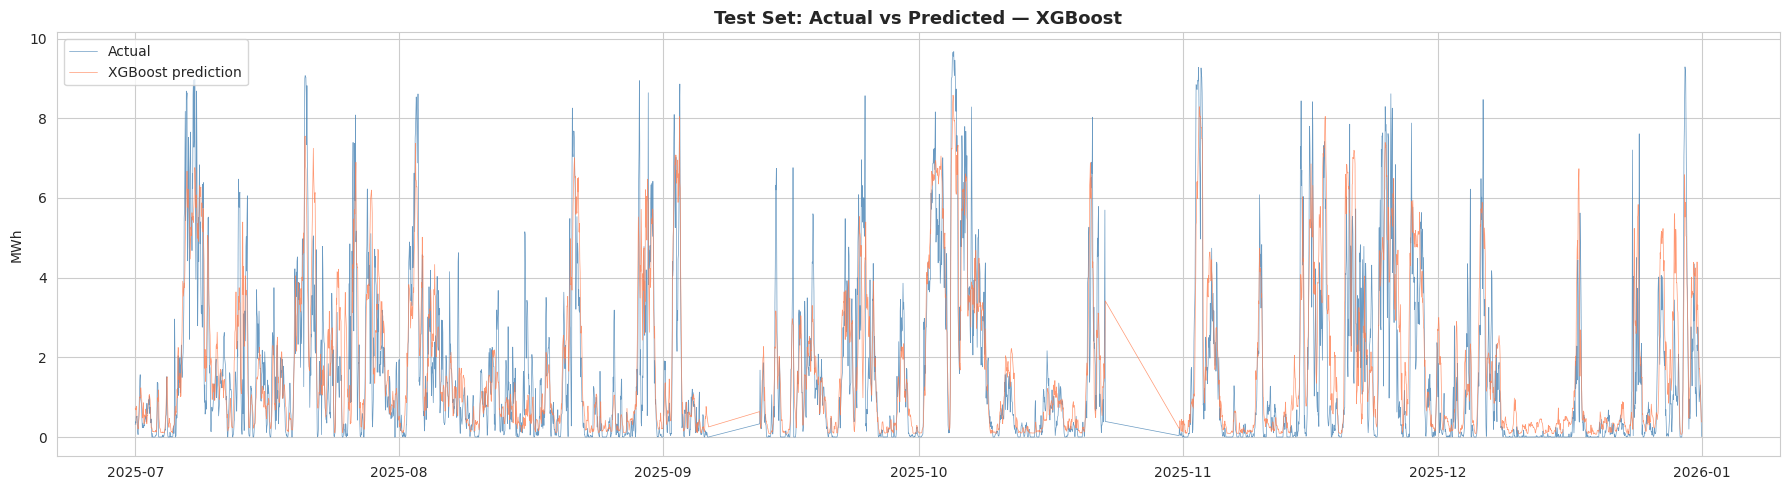

In [16]:
bp = test_preds[best]
va = pd.DataFrame({'actual': y_test.values, 'pred': bp}, index=y_test.index)
va['ae'] = np.abs(va['pred']-va['actual']); va['se'] = va['pred']-va['actual']

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(va.index, va['actual'], lw=0.5, alpha=0.8, label='Actual', color='steelblue')
ax.plot(va.index, va['pred'], lw=0.5, alpha=0.8, label=f'{best} prediction', color='coral')
ax.set_title(f'Test Set: Actual vs Predicted — {best}', fontweight='bold')
ax.set_ylabel('MWh'); ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "results_actual_vs_pred.png", bbox_inches='tight')
plt.show()

The predicted series (coral) tracks the actual production (blue) closely
in shape — the model correctly identifies when the plant is calm and when it is
producing. Two systematic issues are visible: (1) the model **underestimates the
peaks** — predicted peaks rarely reach the highest actuals (8–9 MWh), which is a
well-known limitation of regression on heavy-tailed targets; and (2) over the full
6-month period the model spends more time slightly *above* the actual baseline than
below, which is the visual manifestation of the positive bias (+660 MWh on $E_f$).
Overall, the hour-to-hour correlation is strong, but the cumulative drift is what
costs the model on the $E_f$ metric.

### 8.5 Feature Importance

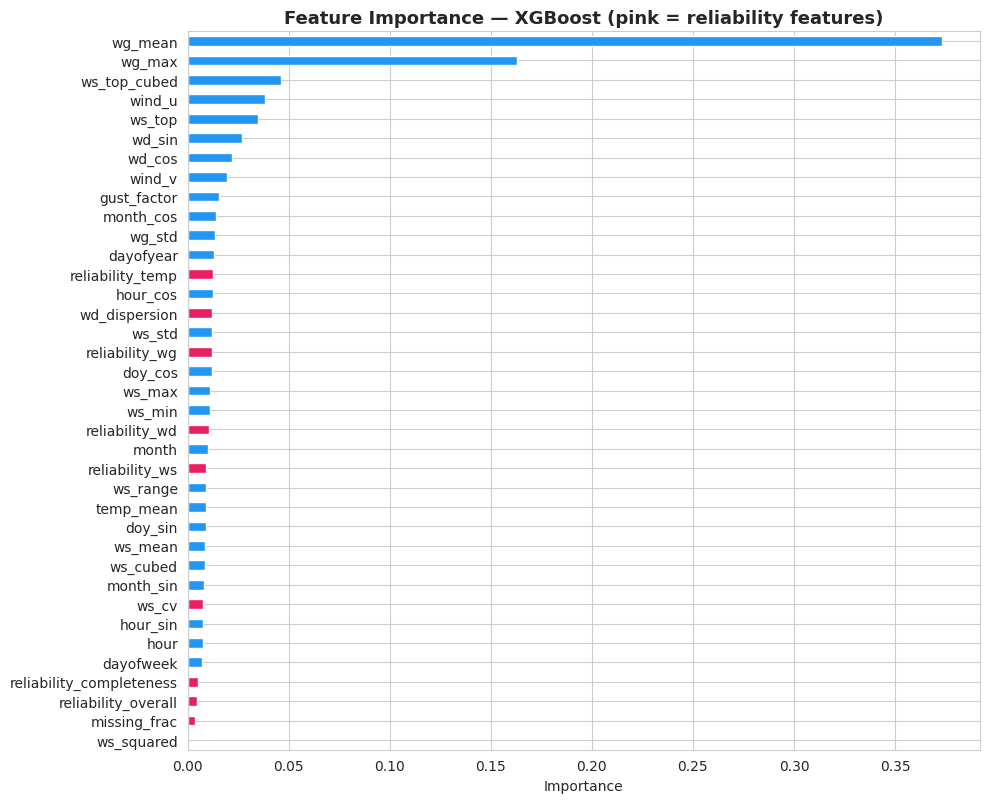

Top 8 features:
  0.0193  wind_v
  0.0219  wd_cos
  0.0271  wd_sin
  0.0349  ws_top
  0.0383  wind_u
  0.0459  ws_top_cubed
  0.1628  wg_max
  0.3734  wg_mean


In [17]:
imp = pd.Series(trained['XGBoost'].feature_importances_, index=fc).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(7, len(imp)*0.22)))
ci = ['#E91E63' if ('reliability' in n or n in ['missing_frac','ws_cv','wd_dispersion'])
      else '#2196F3' for n in imp.index]
imp.plot(kind='barh', ax=ax, color=ci)
ax.set_title('Feature Importance — XGBoost (pink = reliability features)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(OUT_DIR / "results_feature_importance.png", bbox_inches='tight')
plt.show()

print("Top 8 features:")
for n, v in imp.tail(8).items():
    print(f"  {v:.4f}  {n}")

 XGBoost concentrates its attention heavily on the **wind gust** features
(`wg_mean` at ≈0.37 and `wg_max` at ≈0.16 together account for over half the total
importance). This is a striking finding: gust outranks even the engineered `ws_cubed`
and `ws_top` features. The interpretation is physical — gusts capture short-term peak
wind energy, which drives instantaneous production better than smoothed mean wind
speeds. Other top contributors are the directional wind components (`wind_u`, `wind_v`,
`wd_sin`, `wd_cos`), confirming that *which direction* the wind blows matters as much
as how strong it is — wind farms have preferred orientations. The reliability features
(pink) contribute little individually but together provide useful regularization
signal: they tell the model which timestamps to trust.

## 9. Discussion

Bagging vs Boosting.
All five tree ensemble models capture the non-linear wind power curve automatically and handle the noisy, high-dimensional weather inputs robustly. The boosting variants (XGBoost, LightGBM, CatBoost) edge ahead of bagging (Random Forest, Extra Trees), and XGBoost ranks first on E_f, though its lead over the other models is small and driven mainly by lower bias rather than better raw accuracy.

The dominant finding: all models systematically over-predict.
Every model has a large positive bias on the test set (roughly +660 to +800 MWh): they forecast more production than actually occurred between July and December 2025. Because this is consistent across all five models, the cause lies in the data, not the algorithm. The training mean production (1.734 MWh) is higher than the test mean (1.588 MWh): the models learned from a windier period and carried that expectation into a calmer one. This distribution shift is the single largest contributor to E_f.

Why the validation winner (CatBoost) was not the test winner.
On the 3-month internal validation slice, CatBoost had the lowest bias (+7 MWh), making it the apparent best model. On the held-out 6-month test set, however, CatBoost has the highest bias of the five models (+800 MWh) and ranks last. The low-bias advantage did not transfer across time periods — a cautionary lesson about single-window model selection.

Role of the dataset structure:

High dimensionality + noise (235 partially-disagreeing weather columns) means all five tree models cluster tightly together; no single one has a decisive accuracy edge.
Distribution shift + high variance, low seasonality of wind set the ceiling: the best model reaches only R² ≈ 0.67 and over-predicts systematically. The irreducible error and the train/test shift are properties of the data, not the choice of algorithm.